In [1]:
import os
import random
import pickle as pkl
from tqdm import tqdm
import math

from dataclasses import dataclass

from scipy.stats import entropy

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.special import softmax
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import pipeline
import pandas as pd

from collections import Counter

from personal_llm.utils import *
from scipy.stats import dirichlet

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']


In [2]:
def get_person_choices(w_person, data, reward_models, n_response, all_rm_scores, rank_ind=0):

    person_choices = []
    for i in range(len(data)):

        row = data.iloc[i]
        item_scores = []
        for rm_idx, rm in enumerate(reward_models):
            rm_scores = all_rm_scores[i,rm_idx,:]
            rm_scores = rm_scores * w_person[rm_idx]
            # rm_scores = softmax(np.array(rm_scores)) * w_person[rm_idx]
            item_scores.append(rm_scores)

        item_scores = np.array(item_scores)
        item_scores = np.sum(item_scores, 0)
        sorted_ind = np.argsort(-item_scores)
        person_choices.append(sorted_ind[rank_ind])

    return person_choices
 

In [3]:
@dataclass
class Args:
    seed: int=0
    alpha: float=0.05
    n_persons: int=1000
    quantity_on_hand: int = 0
    worst_response: bool=False
    softmax: bool=False
    n_response: int=8


args = Args()

In [4]:
_, reward_models = get_persons_and_reward_models()
train_data, test_data = get_data()

In [5]:
data = test_data

n_rm = len(reward_models)

all_rm_scores = []
for i in range(len(data)):

    row = data.iloc[i]
    item_scores = []
    for rm_idx, rm in enumerate(reward_models):
        rm_scores = []
        for j in range(args.n_response):
            score = row["response_{}_{}".format(j+1, rm)]
            rm_scores.append(score)
        rm_scores = np.array(rm_scores)
        item_scores.append(rm_scores)
    all_rm_scores.append(item_scores)
    
all_rm_scores = np.array(all_rm_scores)
print(all_rm_scores.shape)

exp_data = {}

alpha_list = [0.01, 0.05, 0.1]

for alpha in alpha_list:
    args = Args(
        alpha=alpha,
        # n_persons=1000
    )

    np.random.seed(args.seed)
    random.seed(args.seed)
    torch.manual_seed(args.seed)

    alphas = np.array([args.alpha]*n_rm)
    print("alphas", alphas)
    persons = dirichlet.rvs(alphas, size=args.n_persons, random_state=args.seed)
    print("persons", persons.shape)

    all_choices = []
    for i in tqdm(range(persons.shape[0])):
        person = persons[i]
        choices = get_person_choices(person, data, reward_models, args.n_response, all_rm_scores, rank_ind=0)
        all_choices.append(choices)
    best_choices = np.array(all_choices).T
    print(best_choices.shape)

    all_choices = []
    for i in tqdm(range(persons.shape[0])):
        person = persons[i]
        choices = get_person_choices(person, data, reward_models, args.n_response, all_rm_scores, rank_ind=-1)
        all_choices.append(choices)
    worst_choices = np.array(all_choices).T
    print(worst_choices.shape)

    exp_data[str(alpha)] = {
        "persons": persons, 
        "choices": best_choices,
        "worst": worst_choices
    }

(1000, 10, 8)
alphas [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
persons (1000, 10)


100%|██████████| 1000/1000 [01:28<00:00, 11.30it/s]


(1000, 1000)


100%|██████████| 1000/1000 [01:27<00:00, 11.40it/s]


(1000, 1000)
alphas [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
persons (1000, 10)


...

(1000, 1000)
alphas [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
persons (1000, 10)


100%|██████████| 1000/1000 [01:27<00:00, 11.45it/s]


(1000, 1000)


100%|██████████| 1000/1000 [01:29<00:00, 11.19it/s]

(1000, 1000)


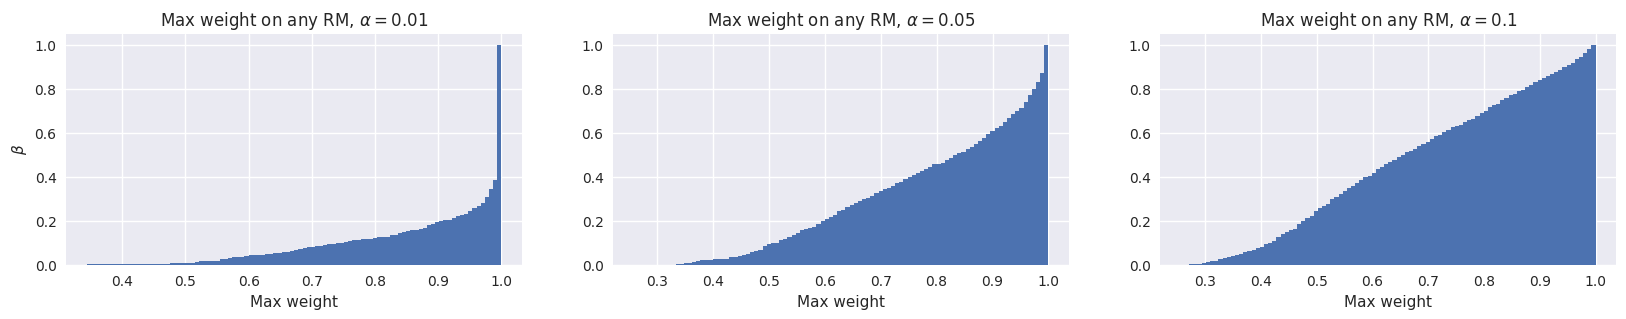

In [6]:
plt.rcParams["figure.figsize"] = (20,3)
fig, axs = plt.subplots(1,len(alpha_list))

for i, alpha in enumerate(alpha_list):
    a_data = exp_data[str(alpha)]
    a_persons = a_data["persons"]
    a_choices = a_data["choices"]

    axs[i].hist(np.max(a_persons, -1), bins=100, density=True, cumulative=True)
    axs[i].set_title(r"Max weight on any RM, $\alpha={}$".format(alpha))
    axs[i].set_xlabel("Max weight")

axs[0].set_ylabel(r"$\beta$")

# plt.legend()
plt.savefig("../plots/alpha_comp_max_weight.png", bbox_inches="tight", dpi=300)
plt.show()

In [7]:
persona_prompt_best = np.load("../data/persona_prompt_best.npy").T
persona_prompt_worst = np.load("../data/persona_prompt_worst.npy").T

print((persona_prompt_best.shape, persona_prompt_worst.shape))

exp_data[str(1.0)] = {
    "persons": np.ones(persona_prompt_best.shape[1]), 
    "choices": persona_prompt_best,
    "worst": persona_prompt_worst,
}
if 1.0 not in alpha_list:
    alpha_list.append(1.0)
alpha_list

((1000, 500), (1000, 500))


[0.01, 0.05, 0.1, 1.0]

As alpha increases, max weight on any reward model decreases

In [8]:
exp_data["0.1"]["choices"].shape, exp_data["0.1"]["persons"].shape, exp_data["1.0"]["choices"].shape, exp_data["1.0"]["persons"].shape

((1000, 1000), (1000, 10), (1000, 500), (500,))

In [12]:
# SAVE EXP DATA
with open("exp_data.pkl", "wb") as f:
    pkl.dump((alpha_list, exp_data, data), f)

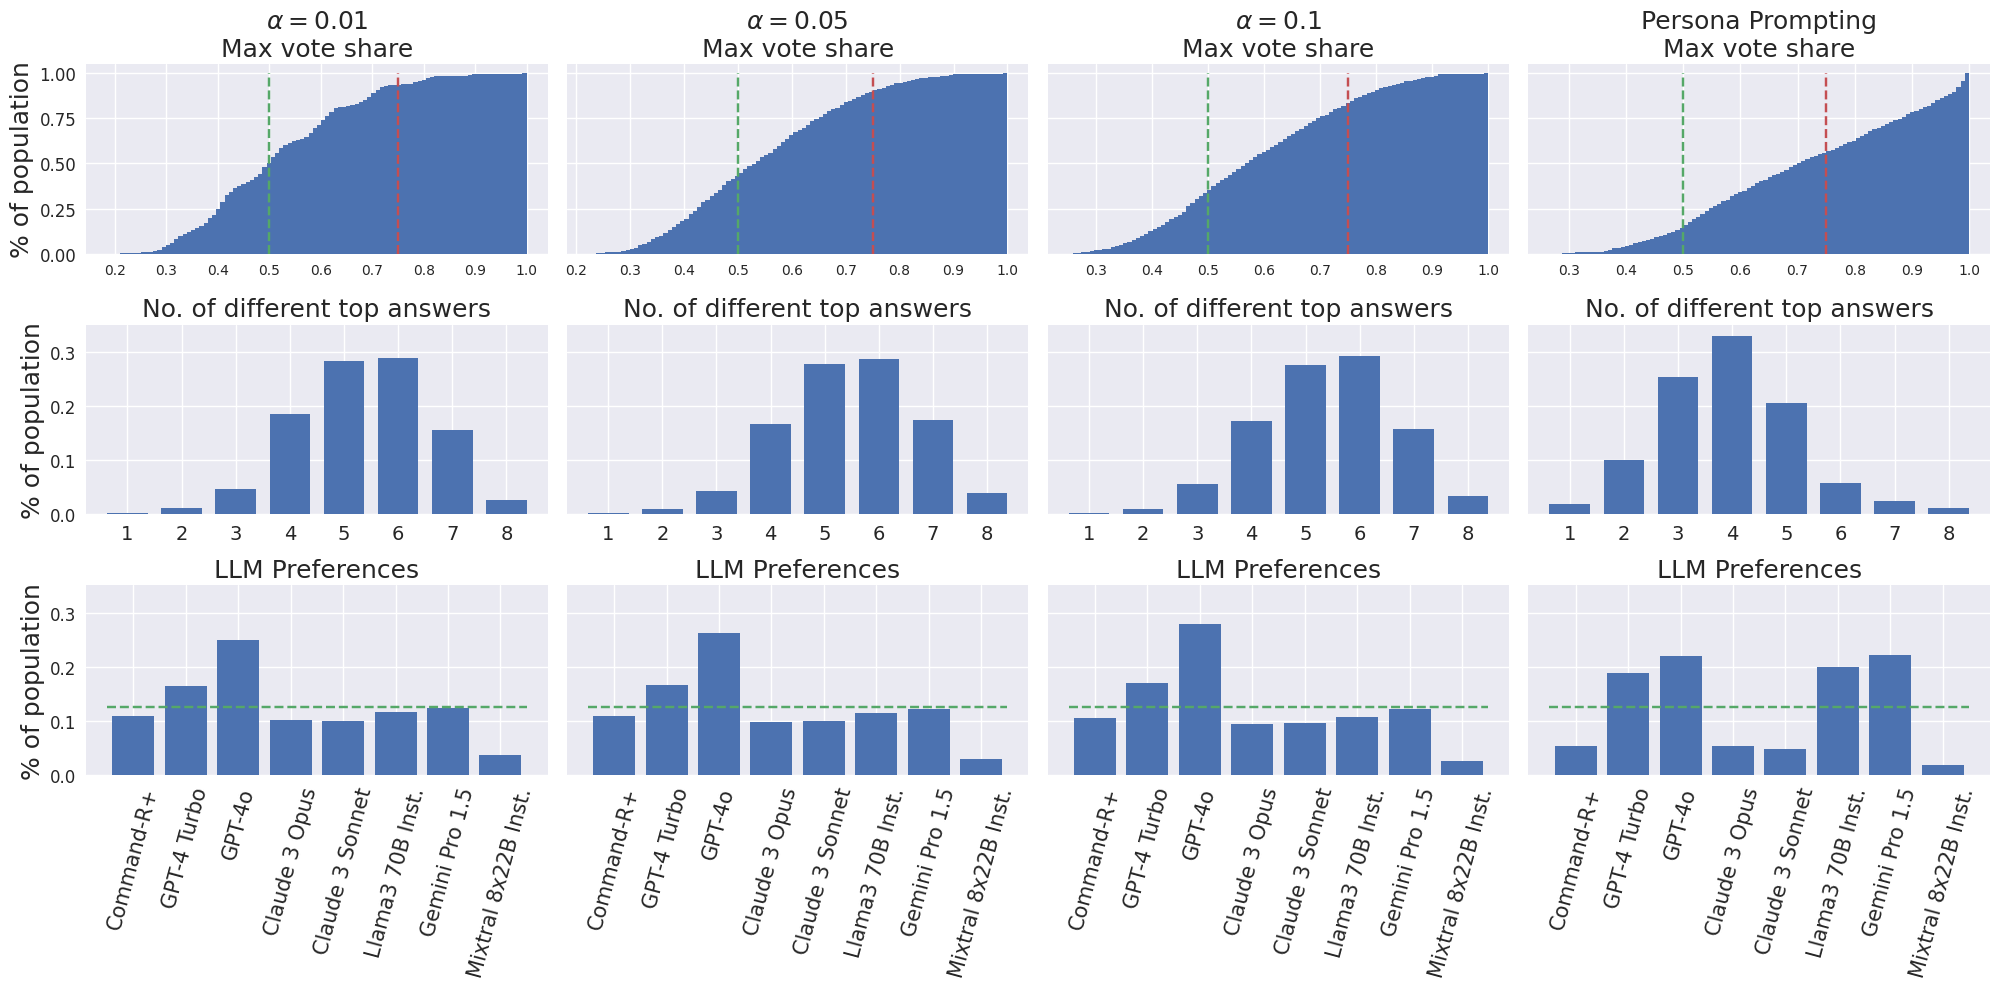

In [21]:
models_map = {
    'command-r-plus': "Command-R+", 
    'gpt-4-turbo': "GPT-4 Turbo", 
    'gpt-4o': "GPT-4o", 
    'claude-3-opus': "Claude 3 Opus", 
    'claude-3-sonnet': "Claude 3 Sonnet", 
    'llama-3-70b-instruct': "Llama3 70B Inst.", 
    'gemini-pro-1.5': "Gemini Pro 1.5", 
    'mixtral-8x22b-instruct': "Mixtral 8x22B Inst."
}

models = []
for i in range(args.n_response):
    model_name = data.iloc[0]["response_{}_model".format(i+1)]
    models.append(model_name)
    assert data.iloc[0]["response_{}_model".format(i+1)] == data.iloc[1]["response_{}_model".format(i+1)]


plt.rcParams["figure.figsize"] = (20,10)
fig, axs = plt.subplots(3,len(alpha_list))

for i, alpha in enumerate(alpha_list):
    a_data = exp_data[str(alpha)]
    a_persons = a_data["persons"]
    a_choices = a_data["choices"]


    max_counts = []
    diff_counts = []
    for j in range(a_choices.shape[0]):
        # print(a_choices[j].shape)
        # e += 7
        counts = Counter(a_choices[j])
        max_count = np.max(list(counts.values()))
        max_counts.append(max_count)
        diff_counts.append(len(counts))

    max_counts = np.array(max_counts)
    max_pct = max_counts/a_persons.shape[0]
    diff_counts = np.array(diff_counts)

    ############################################
    # Top vote share CDF
    ############################################

    max_pct_count = Counter(max_pct)
    axs[0,i].hist(
        max_pct, 
        cumulative=True,
        density=True,
        bins=100
    )
    axs[0,i].plot([0.5, 0.5], [0.0, 1.0], "--")
    axs[0,i].plot([0.75, 0.75], [0.0, 1.0], "--")

    if alpha != 1.0:

        axs[0, i].set_title(r"$\alpha={}$".format(alpha)+"\nMax vote share", fontsize=18)
    else:
        axs[0, i].set_title("Persona Prompting\nMax vote share", fontsize=18)
    
    # plt.tick_params(axis='both', labelsize=12)

    dc_count = Counter(diff_counts)
    X = list(dc_count.keys())
    y = np.array(list(dc_count.values()))
    X, y = zip(*sorted(zip(X, y)))
    y = np.array(y)/len(diff_counts)
    axs[1,i].bar(X, y, width = 0.75)
    axs[1,i].set_xticks(X)
    axs[1,i].tick_params(axis='y')
    axs[1,i].tick_params(axis='x', labelsize=14)
    axs[1,i].set_title("No. of different top answers", fontsize=18)
    

    axs[1,i].set_ylim(0.0, 0.4)

    unique, counts = np.unique(a_choices, return_counts=True)
    models_list = [models[u].split("/")[-1].split(":")[0] for u in unique]

    total_items = np.sum(np.ones_like(a_choices))

    pcts = counts/total_items
    axs[2,i].bar([models[u] for u in unique], pcts)
    axs[2,i].plot([-0.5, len(models)-0.5], [np.mean(pcts), np.mean(pcts)], "--", color=pal[1])
    
    axs[2,i].set_title(r"LLM Preferences", fontsize=18)
    axs[2,i].set_xticks(unique, [models_map[m] for m in models_list], rotation=75, size=15)
    axs[2,i].tick_params(axis='x')
    axs[2,i].tick_params(axis='y')

    axs[1,i].set_ylim(0.0, 0.35)
    axs[2,i].set_ylim(0.0, 0.35)

    if i != 0:
        axs[0,i].set_yticklabels([])
        axs[1,i].set_yticklabels([])
        axs[2,i].set_yticklabels([])

    axs[0,i].tick_params(axis='y', labelsize=12)
    axs[1,i].tick_params(axis='y', labelsize=12)
    axs[2,i].tick_params(axis='y', labelsize=12)

for i in range(len(axs)):

    axs[i,0].set_ylabel(r"% of population", fontsize=18)

# axs[1,0].set_ylabel("Density")


fig.tight_layout()
plt.savefig("../plots/persona_prompting_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

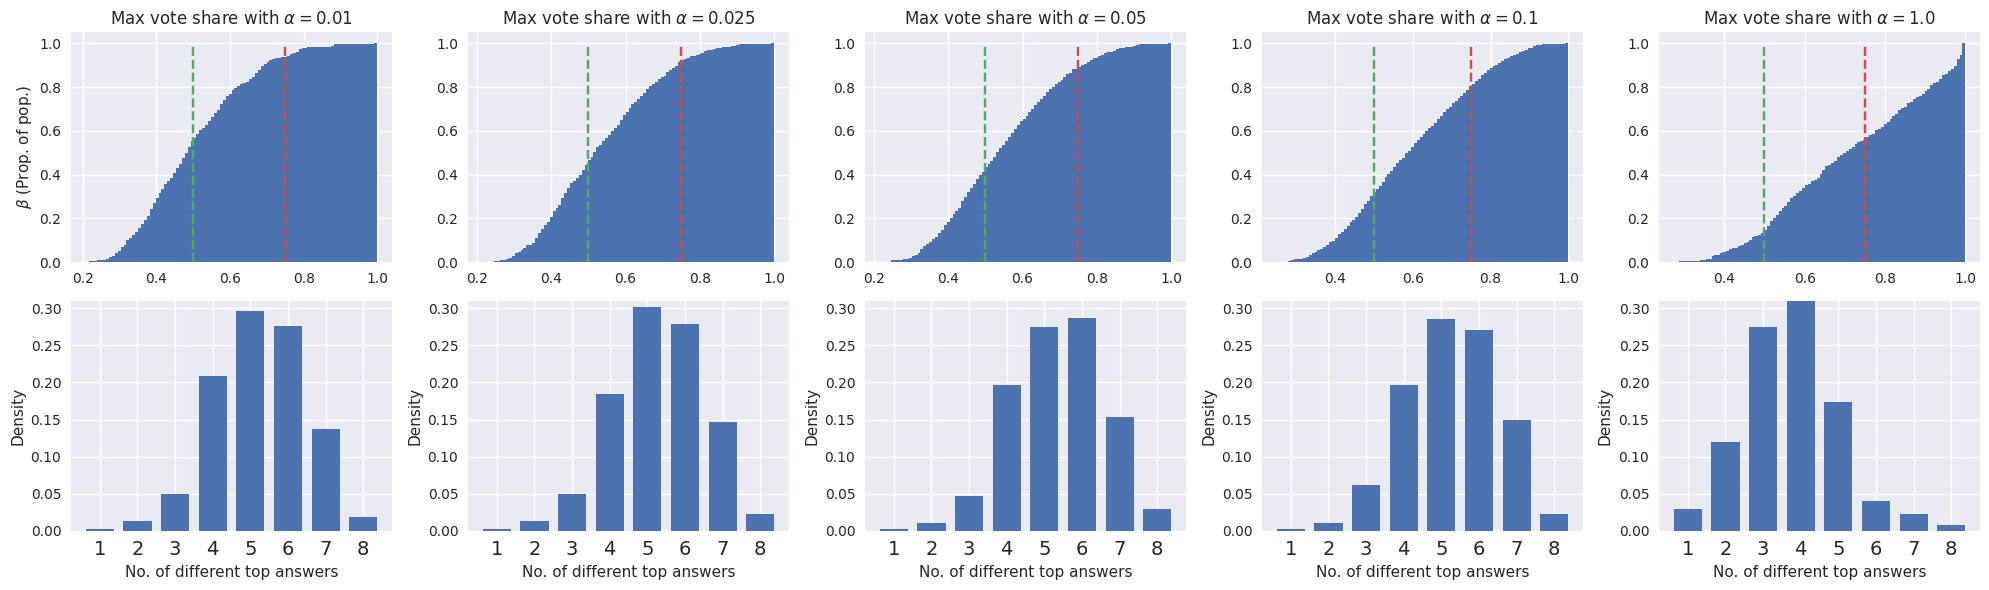

In [32]:
models_map = {
    'command-r-plus': "Command-R+", 
    'gpt-4-turbo': "GPT-4 Turbo", 
    'gpt-4o': "GPT-4o", 
    'claude-3-opus': "Claude 3 Opus", 
    'claude-3-sonnet': "Claude 3 Sonnet", 
    'llama-3-70b-instruct': "Llama3 70B Inst.", 
    'gemini-pro-1.5': "Gemini Pro 1.5", 
    'mixtral-8x22b-instruct': "Mixtral 8x22B Inst."
}

models = []
for i in range(args.n_response):
    model_name = data.iloc[0]["response_{}_model".format(i+1)]
    models.append(model_name)
    assert data.iloc[0]["response_{}_model".format(i+1)] == data.iloc[1]["response_{}_model".format(i+1)]


plt.rcParams["figure.figsize"] = (20,6)
fig, axs = plt.subplots(3,len(alpha_list))

for i, alpha in enumerate(alpha_list):
    a_data = exp_data[str(alpha)]
    a_persons = a_data["persons"]
    a_choices = a_data["choices"]


    max_counts = []
    diff_counts = []
    for j in range(a_choices.shape[0]):
        # print(a_choices[j].shape)
        # e += 7
        counts = Counter(a_choices[j])
        max_count = np.max(list(counts.values()))
        max_counts.append(max_count)
        diff_counts.append(len(counts))

    max_counts = np.array(max_counts)
    max_pct = max_counts/a_persons.shape[0]
    diff_counts = np.array(diff_counts)

    ############################################
    # Top vote share CDF
    ############################################

    max_pct_count = Counter(max_pct)
    axs[0,i].hist(
        max_pct, 
        cumulative=True,
        density=True,
        bins=100
    )
    axs[0,i].plot([0.5, 0.5], [0.0, 1.0], "--")
    axs[0,i].plot([0.75, 0.75], [0.0, 1.0], "--")

    axs[0, i].set_title(r"Max vote share with $\alpha={}$".format(alpha))
    
    # plt.tick_params(axis='both', labelsize=12)

    dc_count = Counter(diff_counts)
    X = list(dc_count.keys())
    y = np.array(list(dc_count.values()))
    X, y = zip(*sorted(zip(X, y)))
    y = np.array(y)/len(diff_counts)
    axs[1,i].bar(X, y, width = 0.75)
    axs[1,i].set_xticks(X)
    axs[1,i].tick_params(axis='y')
    axs[1,i].tick_params(axis='x', labelsize=14)
    axs[1,i].set_xlabel("No. of different top answers")
    axs[1,i].set_ylabel("Density")

    axs[1,i].set_ylim(0.0, 0.31)

    unique, counts = np.unique(a_choices, return_counts=True)
    models_list = [models[u].split("/")[-1].split(":")[0] for u in unique]

    total_items = np.sum(np.ones_like(a_choices))

    pcts = counts/total_items
    axs[2,i].bar([models[u] for u in unique], pcts)
    axs[2,i].plot([-0.5, len(models)-0.5], [np.mean(pcts), np.mean(pcts)], "--", color=pal[1])
    
    axs[2,i].set_xticks([])
    axs[2,i].tick_params(axis='y', labelsize=12)
    
    axs[2,i].set_title(r"LLM Preferences, $\alpha={}$".format(alpha))
    axs[2,i].set_ylim(0.0, 0.3)

axs[0,0].set_ylabel(r"$\beta$ (Prop. of pop.)")

fig.tight_layout()
plt.savefig("../plots/alpha_comp_vote_shares.png", bbox_inches="tight", dpi=300)
plt.show()

As alpha increases, max vote share increases

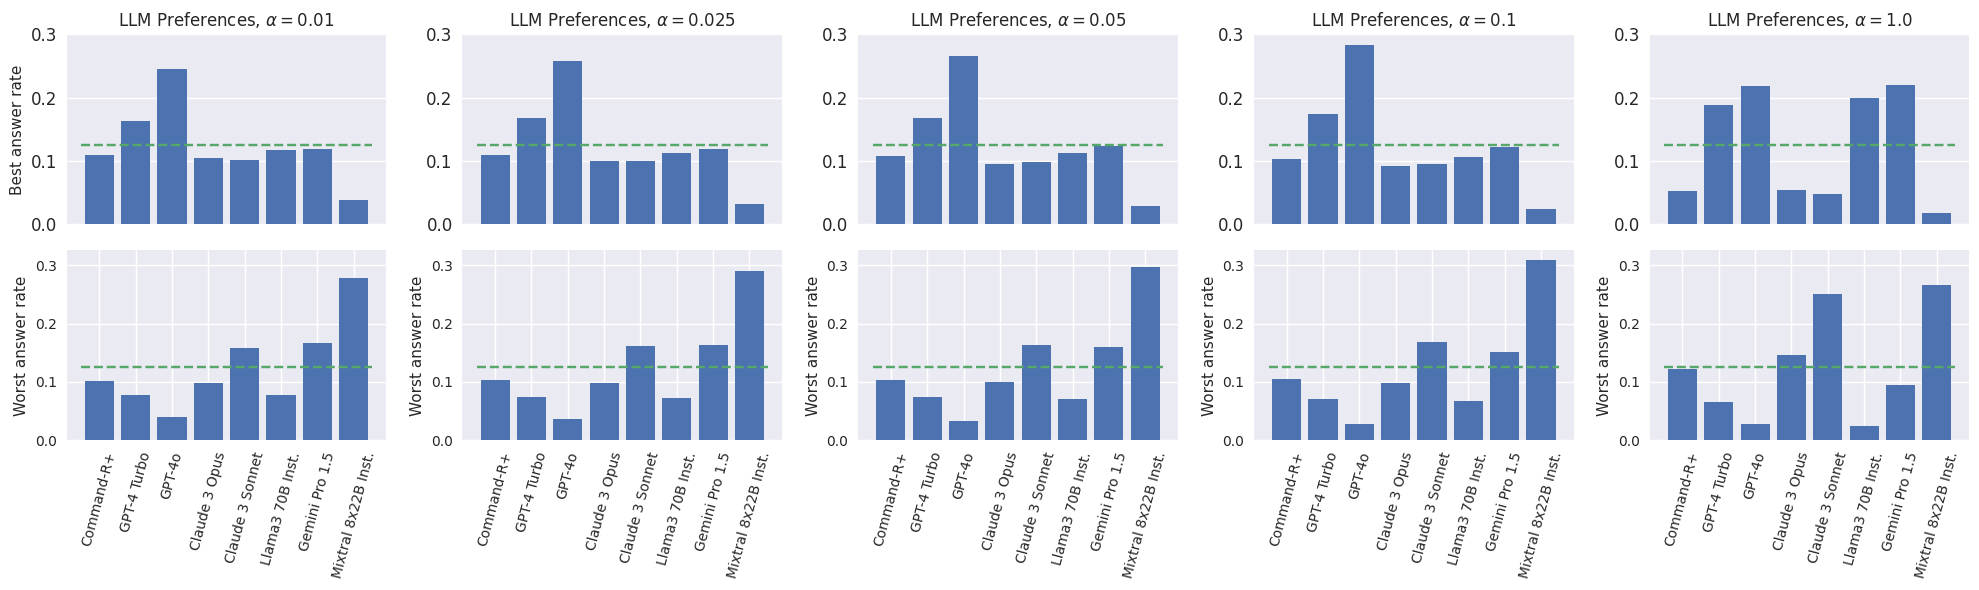

In [33]:
plt.rcParams["figure.figsize"] = (20,6)
fig, axs = plt.subplots(2,len(alpha_list))

models_map = {
    'command-r-plus': "Command-R+", 
    'gpt-4-turbo': "GPT-4 Turbo", 
    'gpt-4o': "GPT-4o", 
    'claude-3-opus': "Claude 3 Opus", 
    'claude-3-sonnet': "Claude 3 Sonnet", 
    'llama-3-70b-instruct': "Llama3 70B Inst.", 
    'gemini-pro-1.5': "Gemini Pro 1.5", 
    'mixtral-8x22b-instruct': "Mixtral 8x22B Inst."
}

models = []
for i in range(args.n_response):
    model_name = data.iloc[0]["response_{}_model".format(i+1)]
    models.append(model_name)
    assert data.iloc[0]["response_{}_model".format(i+1)] == data.iloc[1]["response_{}_model".format(i+1)]

for i, alpha in enumerate(alpha_list):
    a_data = exp_data[str(alpha)]
    a_persons = a_data["persons"]
    a_choices = a_data["choices"]
    a_worst_choices = a_data["worst"]

    ############################################
    # Win Rate
    ############################################
    

    unique, counts = np.unique(a_choices, return_counts=True)
    models_list = [models[u].split("/")[-1].split(":")[0] for u in unique]

    total_items = np.sum(np.ones_like(a_choices))

    pcts = counts/total_items
    axs[0,i].bar([models[u] for u in unique], pcts)
    axs[0,i].plot([-0.5, len(models)-0.5], [np.mean(pcts), np.mean(pcts)], "--", color=pal[1])
    
    axs[0,i].set_xticks([])
    axs[0,i].tick_params(axis='y', labelsize=12)
    
    axs[0,i].set_title(r"LLM Preferences, $\alpha={}$".format(alpha))
    axs[0,i].set_ylim(0.0, 0.3)
        
    ############################################
    # Loss Rate
    ############################################
    unique, counts = np.unique(a_worst_choices, return_counts=True)
    total_items = np.sum(np.ones_like(a_worst_choices))

    pcts = counts/total_items
    axs[1,i].bar([models[u] for u in unique], pcts)
    axs[1,i].plot([-0.5, len(models)-0.5], [np.mean(pcts), np.mean(pcts)], "--", color=pal[1])
    axs[1,i].set_xticks(unique, [models_map[m] for m in models_list], rotation=75)
    axs[1,i].tick_params(axis='x')
    axs[1,i].tick_params(axis='y')
    axs[1,i].set_ylabel("Worst answer rate")

    axs[1,i].set_ylim(0.0, 0.325)
    

    

axs[0,0].set_ylabel("Best answer rate")

fig.tight_layout()
plt.savefig("../plots/alpha_comp_best_worst_llms.png", bbox_inches="tight", dpi=300)
plt.show()

As alpha increases, distribution more peaked (less diversity over base model preferences)

0.01 0.3592881 0.09480162782893023 0.9694699999999998
0.025 0.3939128500000001 0.10876869643883069 0.9605799999999999
0.05 0.41177707500000005 0.1023574578011142 0.9333400000000002
0.1 0.4452251750000001 0.12149961109673098 0.90892
1.0 0.6116676444444444 0.016904369555126766 0.68733


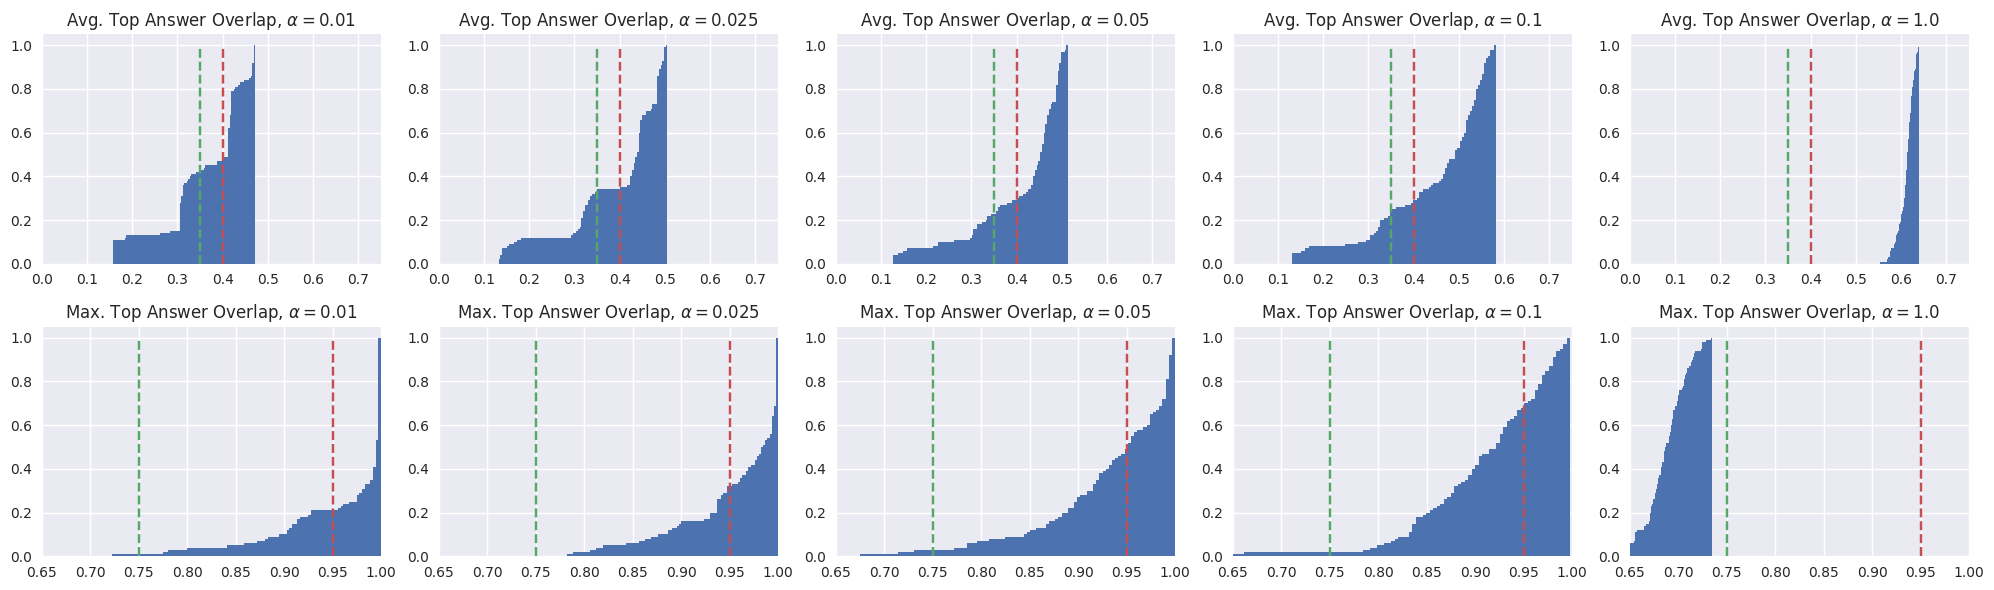

In [34]:
plt.rcParams["figure.figsize"] = (20,6)
fig, axs = plt.subplots(2,len(alpha_list))

for i, alpha in enumerate(alpha_list):

    a_data = exp_data[str(alpha)]
    a_persons = a_data["persons"]
    a_choices = a_data["choices"].T

    # print(a_choices.shape)

    n_targets = 100
    test_persons = a_choices[n_targets:]

    avg_sames = []
    max_sames = []

    for target_idx in range(n_targets):

        target_person = a_choices[target_idx]
        # print(target_person.shape)
        same = (target_person == test_persons)*1
        # print(same.shape)
        avg_same = np.mean(same, -1)
        avg_sames.append(np.mean(avg_same))
        max_sames.append(np.max(avg_same))

    print(alpha, np.mean(avg_sames), np.std(avg_sames), np.mean(max_sames))

    axs[0,i].hist(avg_sames, bins=100, density=True, cumulative=True)
    axs[0,i].plot([0.35, 0.35], [0.0, 1.0], "--")
    axs[0,i].plot([0.4, 0.4], [0.0, 1.0], "--")
    axs[0,i].set_xlim(0.0, 0.75)
    axs[0,i].set_title(r"Avg. Top Answer Overlap, $\alpha={}$".format(alpha))
    
    axs[1,i].hist(max_sames, bins=100, density=True, cumulative=True)
    axs[1,i].plot([0.75, 0.75], [0.0, 1.0], "--")
    axs[1,i].plot([0.95, 0.95], [0.0, 1.0], "--")
    axs[1,i].set_xlim(0.65, 1.0)
    axs[1,i].set_title(r"Max. Top Answer Overlap, $\alpha={}$".format(alpha))

fig.tight_layout()
plt.savefig("../plots/alpha_comp_answer_overlaps.png", bbox_inches="tight", dpi=300)
plt.show()

As alpha increases, get more people that are somewhat similar, less people that are extremely similar
 
 - ex. alpha = 0.01, 40% of the population has < 35% average overlap, 20% of the population has < 95% max overlap
 - ex. alpha = 0.1, 20% of the population has < 35% average overlap, 60% of the population has < 95% max overlap